# <font color="#6e8ebc">**CusTech - Exploratory Data Analysis**</font>

**Indice**


El índice del notebook ha sido actualizado a:

1. <font color="#6e8ebc">**Descripción del Notebook**</font>
2. <font color="#6e8ebc">**Configuraciónes**</font>
   * Cargar paleta de colores
   * Importación de librerías
   * Paths
   * Paleta de Colores del Proyecto
3. <font color="#6e8ebc">**Extracción de Datos**</font>
   * Clientes
   * Transacciones
   * Interacciones con la App
4. <font color="#6e8ebc">**Exploratory Data Analysis (EDA)**</font>
   * Perfil del Cliente
     * Análisis General
     * Por Género
     * Por País
     * Por Edad
     * Por Saldo Bancario
   * Transacciones del Cliente
   * Interacciones del Cliente con la App
   * Análisis Completo: Factores que Influyen en el Abandono
5. <font color="#6e8ebc">**Feature Engineering**</font>
   * Conversión de Columnas de Fecha
   * Identificación y Corrección de Fugas de Datos
   * Agregación de Transacciones por Cliente
   * Agregación de Sesiones por Cliente
   * Unificación de Datos 360
   * Preparación de Datos para Modelado
6. <font color="#6e8ebc">**Modelado Predictivo**</font>
   * Entrenamiento del Modelo de Regresión Logística
   * Análisis de Características Importantes
   * Análisis Estadístico Adicional
7. <font color="#6e8ebc">**Conclusiones y Mejoras**</font>
   * Análisis de Fugas de Datos y Multicolinealidad
   * Resumen Visual de los Hallazgos

##<font color="#ff743d">**Descripción del Proyecto**

El problema del churn de clientes es crítico para las instituciones financieras. Este notebook aborda el análisis del churn mediante la integración de datos de clientes, transacciones e interacciones con la aplicación bancaria. El proceso incluye:

*   **Carga y Limpieza de Datos**: Se cargan los datasets de clientes, transacciones y sesiones de aplicación, y se realiza una limpieza inicial, incluyendo la conversión de tipos de datos y la corrección de posibles fugas de datos.
*   **Análisis Exploratorio de Datos (EDA)**: Se exploran los datos para comprender las distribuciones, identificar patrones y relaciones entre las variables, prestando especial atención a cómo diferentes características de los clientes se relacionan con la tasa de abandono.
*   **Feature Engineering**: Creación de nuevas características a partir de los datos existentes, utilizando ventanas de tiempo para capturar el comportamiento dinámico de los clientes y crear indicadores que permitan prevenir el churn.
*   **Análisis de Multicolinealidad (VIF)**: Se evalúa la multicolinealidad entre las características generadas para asegurar la robustez del modelo predictivo.

## Estructura del Repositorio

```
. (raíz del proyecto)
├── img/                                # Directorio para imágenes y visualizaciones
│   └── EDA_img/                        # Imágenes específicas del Análisis Exploratorio de Datos
├── models/                             # Directorio para almacenar modelos entrenados
├── reports/                            # Directorio para informes o resultados generados
├── clients.parquet                  # Archivo de datos de clientes
├── transactions.parquet             # Archivo de datos de transacciones
├── app_sessions.parquet             # Archivo de datos de sesiones de aplicación
├── churn_analysis_notebook.ipynb       # Notebook principal del proyecto
└── README.md                           # Este archivo (descripción del proyecto)

## <font color="#ff743d">**Definicion de paleta de colores**</font>




In [325]:
NARANJA_1, NARANJA_2, NARANJA_3, NARANJA_4, NARANJA_5 = '#993c00', '#cc5a00', '#ff7b00', '#ff9c40', '#ffbf80'
ROJO_1, ROJO_2, ROJO_3, ROJO_4, ROJO_5 = '#7a1c00', '#b23200', '#e74903', '#ff743d', '#ffa68c'
AZUL_1, AZUL_2, AZUL_3, AZUL_4, AZUL_5 = '#001a37', '#002b5c', '#003873', '#315c99', '#6e8ebc'
CIELO_1, CIELO_2, CIELO_3, CIELO_4, CIELO_5 = '#004752', '#007789', '#00b5d0', '#40cee6', '#8ae6f4'


## <font color="#ff743d">**Importación de librerías**</font>

In [326]:
# Importar bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from scipy.stats import chi2_contingency
import warnings
from pathlib import Path
import os
warnings.filterwarnings('ignore')

# Configurar estilo de gráficos
plt.style.use('default')
palette_colors = [AZUL_3, CIELO_3, NARANJA_3, ROJO_3, AZUL_4, CIELO_4, NARANJA_4, ROJO_4, AZUL_5, CIELO_5]
sns.set_palette(palette_colors)

print("Bibliotecas importadas correctamente")

Bibliotecas importadas correctamente


In [1]:
exited_colors = [CIELO_2, NARANJA_3]

NameError: name 'CIELO_2' is not defined

In [327]:
import subprocess

# Comando para generar el requirements.txt
command = f"pip freeze > {PROJECT_PATH / 'requirements.txt'}"

# Ejecutar el comando en el shell
try:
    subprocess.run(command, shell=True, check=True)
    print(f"'requirements.txt' generado exitosamente en: {PROJECT_PATH}")
except subprocess.CalledProcessError as e:
    print(f"Error al generar 'requirements.txt': {e}")


'requirements.txt' generado exitosamente en: /content


## <font color="#ff743d">**Paths**</font>

In [328]:
# Obtiene el path actual
PROJECT_PATH = Path(os.getcwd())

DATA_PATH = PROJECT_PATH

img = Path('img')
GENERAL_IMG_PATH = PROJECT_PATH / img

EDA_img = Path('EDA_img')
IMG_PATH = GENERAL_IMG_PATH / EDA_img

models = Path('models')
MODELS_PATH = PROJECT_PATH / models

reports = Path('reports')
REPORTS_PATH = PROJECT_PATH / reports

dirs = [DATA_PATH, IMG_PATH, MODELS_PATH, REPORTS_PATH]


for directory in dirs:
    if not directory.exists():
        directory.mkdir(parents=True)
        print(f'Directorio creado:\n{directory}\n')
    else:
        print(f'El directorio ya existe:\n{directory}\n')

El directorio ya existe:
/content

El directorio ya existe:
/content/img/EDA_img

El directorio ya existe:
/content/models

El directorio ya existe:
/content/reports



In [329]:
print('Cargando datasets...')

# Carga de los archivos .parquet como su formato original
clients_df = pd.read_parquet(DATA_PATH / 'clients(1).parquet')
transactions_df = pd.read_parquet(DATA_PATH / 'transactions(1).parquet')
app_sessions_df = pd.read_parquet(DATA_PATH / 'app_sessions(1).parquet')

print('Datasets cargados exitosamente:')
print(f' - clients_df: {clients_df.shape[0]} filas, {clients_df.shape[1]} columnas')
print(f' - transactions_df: {transactions_df.shape[0]} filas, {transactions_df.shape[1]} columnas')
print(f' - app_sessions_df: {app_sessions_df.shape[0]} filas, {app_sessions_df.shape[1]} columnas')

Cargando datasets...
Datasets cargados exitosamente:
 - clients_df: 10000 filas, 16 columnas
 - transactions_df: 1022383 filas, 5 columnas
 - app_sessions_df: 537697 filas, 10 columnas


## <font color="#ff743d">**Análisis General de Clientes**:

**Objetivo**: Entender la distribución general de la población de clientes y la proporción de aquellos que han abandonado el servicio.

**Hallazgos Clave**: Se visualiza la tasa de abandono global, ofreciendo una primera perspectiva sobre la magnitud del problema. Por ejemplo, se identificó una tasa de abandono del 20.37% en la base de clientes.

**Visualizaciones Relevantes**: Gráfico de pastel (`plt.pie`) mostrando

--- Información General de Clientes ---
Número total de clientes: 10000
Clientes que dejaron el banco (Churn): 2037
Clientes que se quedaron: 7963
Tasa de abandono: 20.37%


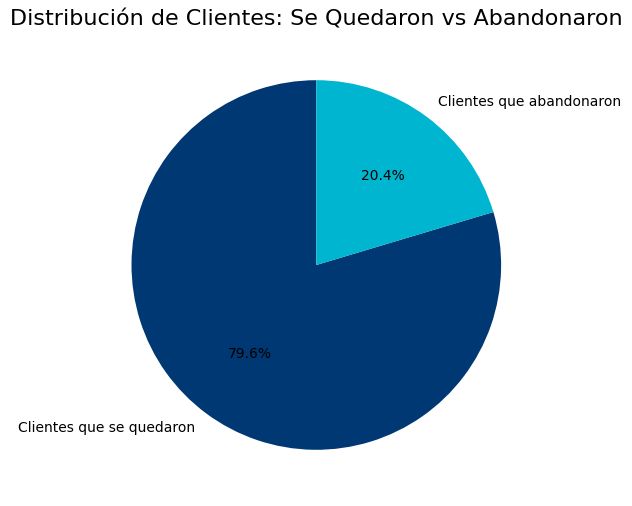

In [330]:
# Análisis general de clientes
print("--- Información General de Clientes ---")
print(f"Número total de clientes: {len(clients_df)}")
print(f"Clientes que dejaron el banco (Churn): {clients_df['Exited'].sum()}")
print(f"Clientes que se quedaron: {len(clients_df) - clients_df['Exited'].sum()}")
print(f"Tasa de abandono: {clients_df['Exited'].mean()*100:.2f}%")

# Visualización de clientes que abandonaron vs se quedaron
plt.figure(figsize=(10, 6))
churn_counts = clients_df['Exited'].value_counts()
labels = ['Clientes que se quedaron', 'Clientes que abandonaron']
colors = palette_colors[:2]
plt.pie(churn_counts.values, labels=labels, autopct='%1.1f%%', startangle=90, colors=exited_colors)
plt.title('Distribución de Clientes: Se Quedaron vs Abandonaron', fontsize=16)
plt.show()

## <font color="#ff743d">**Análisis por Género**:

**Objetivo**: Determinar si existen diferencias significativas en la tasa de abandono entre clientes masculinos y femeninos.

**Hallazgos Clave**: Se observó que las mujeres tienen una tasa de abandono significativamente mayor (25.07%) en comparación con los hombres (16.46%), lo que sugiere que el género es un factor influyente.

**Visualizaciones Relevantes**: Gráficos de barras (`plt.bar`) para la distribución de clientes por género y la tasa de abandono por género.

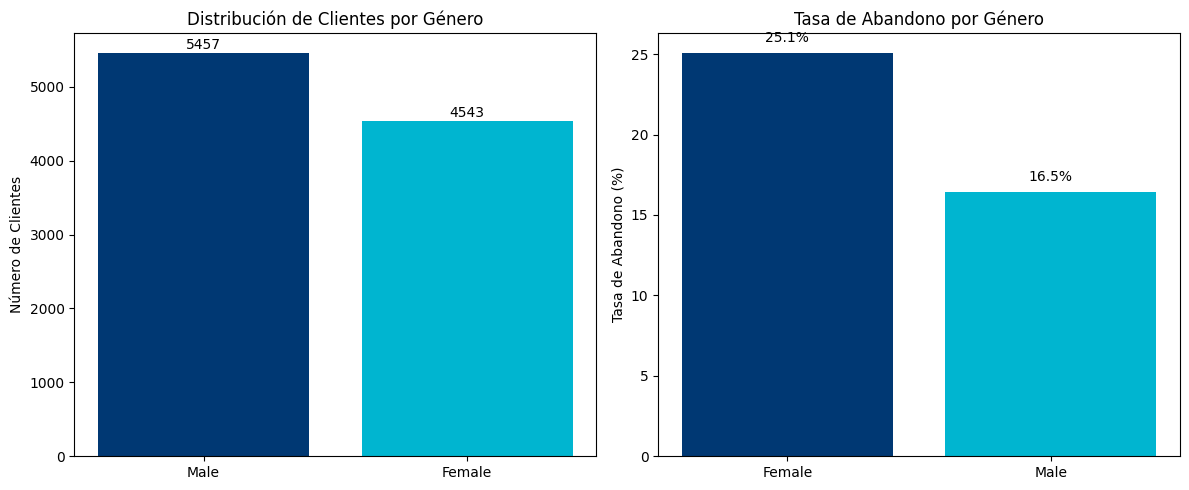

Tasa de abandono por género:
  Female: 25.07%
  Male: 16.46%


In [331]:
# Análisis por género
plt.figure(figsize=(12, 5))

# Gráfico 1: Distribución por género
plt.subplot(1, 2, 1)
gender_counts = clients_df['Gender'].value_counts()
plt.bar(gender_counts.index, gender_counts.values, color=palette_colors[:2])
plt.title('Distribución de Clientes por Género')
plt.ylabel('Número de Clientes')
for i, v in enumerate(gender_counts.values):
    plt.text(i, v + 10, str(v), ha='center', va='bottom')

# Gráfico 2: Tasa de abandono por género
plt.subplot(1, 2, 2)
churn_by_gender = clients_df.groupby('Gender')['Exited'].mean() * 100
plt.bar(churn_by_gender.index, churn_by_gender.values, color=exited_colors)
plt.title('Tasa de Abandono por Género')
plt.ylabel('Tasa de Abandono (%)')
for i, v in enumerate(churn_by_gender.values):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print(f"Tasa de abandono por género:")
for gender, rate in churn_by_gender.items():
    print(f"  {gender}: {rate:.2f}%")

## <font color="#ff743d">**Análisis por País**:

**Objetivo**: Evaluar cómo varía la tasa de abandono en diferentes ubicaciones geográficas de los clientes.

**Hallazgos Clave**: Los clientes de Alemania presentan la tasa de abandono más alta (32.44%), superando notablemente a Francia (16.15%) y España (16.67%). Esto indica que la región geográfica es un predictor importante del churn.

**Visualizaciones Relevantes**: Gráficos de barras (`plt.bar`) mostrando la distribución de clientes por país y la tasa de abandono por país.

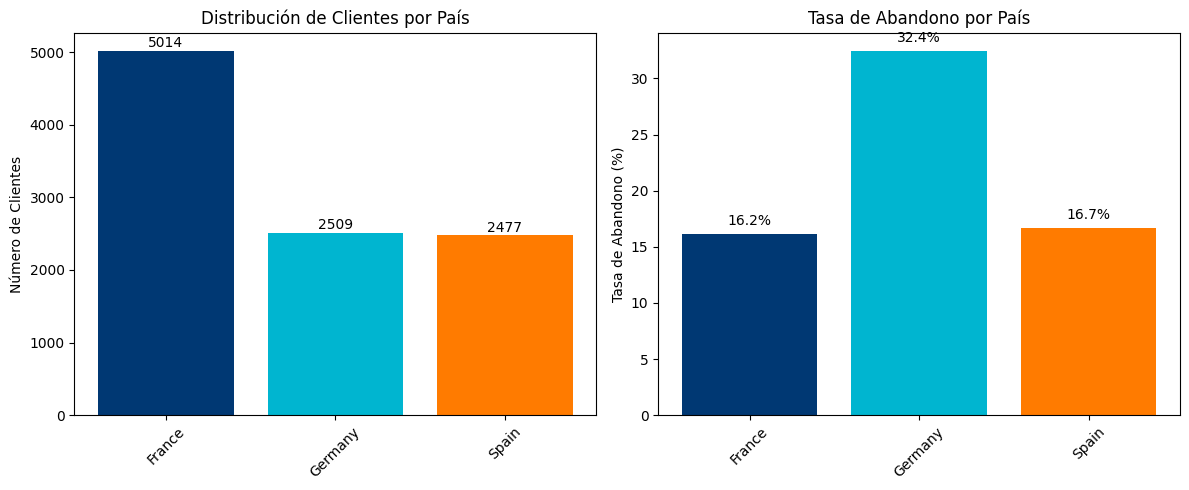

Tasa de abandono por país:
  France: 16.15%
  Germany: 32.44%
  Spain: 16.67%


In [332]:
# Análisis por país
plt.figure(figsize=(12, 5))

# Gráfico 1: Distribución por país
plt.subplot(1, 2, 1)
country_counts = clients_df['Geography'].value_counts()
plt.bar(country_counts.index, country_counts.values, color=palette_colors[:3])
plt.title('Distribución de Clientes por País')
plt.ylabel('Número de Clientes')
plt.xticks(rotation=45)
for i, v in enumerate(country_counts.values):
    plt.text(i, v + 10, str(v), ha='center', va='bottom')

# Gráfico 2: Tasa de abandono por país
plt.subplot(1, 2, 2)
churn_by_country = clients_df.groupby('Geography')['Exited'].mean() * 100
plt.bar(churn_by_country.index, churn_by_country.values, color=palette_colors[:3])
plt.title('Tasa de Abandono por País')
plt.ylabel('Tasa de Abandono (%)')
plt.xticks(rotation=45)
for i, v in enumerate(churn_by_country.values):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print(f"Tasa de abandono por país:")
for country, rate in churn_by_country.items():
    print(f"  {country}: {rate:.2f}%")

## <font color="#ff743d">**Análisis por Edad**:

**Objetivo**: Identificar qué rangos de edad son más propensos a abandonar el banco.

**Hallazgos Clave**: Los clientes en el rango de edad de 50-60 años tienen la tasa de abandono más alta (56.21%), mientras que los menores de 30 años presentan la más baja (7.52%). La edad es un factor crítico en la propensión al churn.

**Visualizaciones Relevantes**: Histograma de la distribución de edad (`plt.hist`), gráfico de barras de la tasa de abandono por grupo de edad (`plt.bar`) y un gráfico de dispersión (`plt.scatter`) explorando la relación entre edad, saldo y abandono.

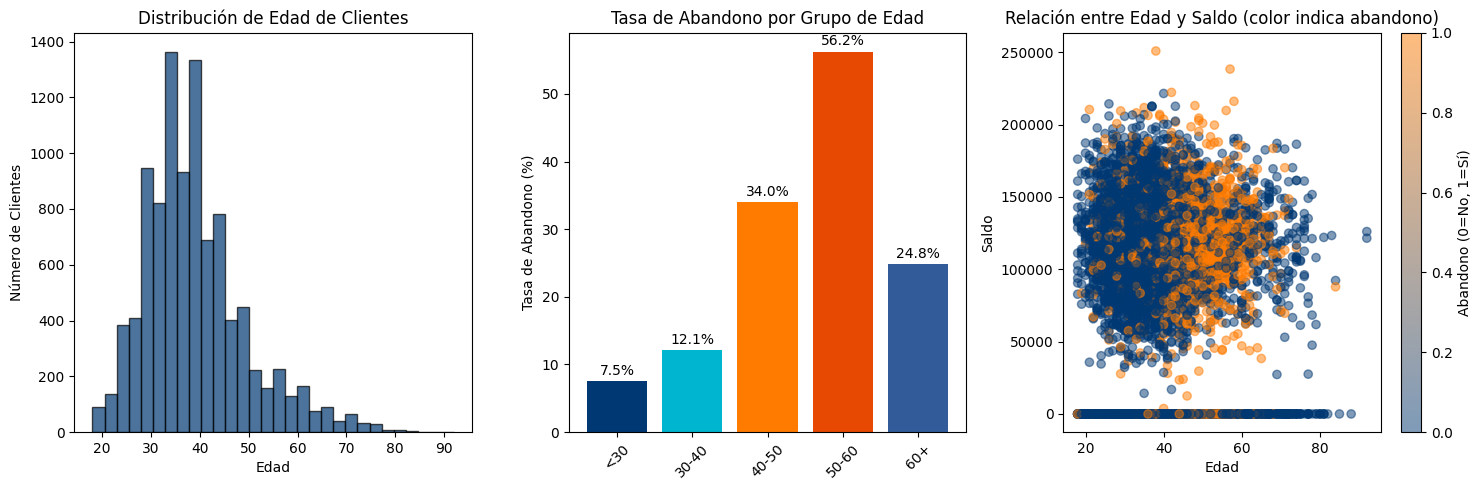

Tasa de abandono por grupo de edad:
  <30: 7.52%
  30-40: 12.09%
  40-50: 33.97%
  50-60: 56.21%
  60+: 24.78%


In [333]:
# Análisis por edad
plt.figure(figsize=(15, 5))

# Histograma de edad
plt.subplot(1, 3, 1)
plt.hist(clients_df['Age'], bins=30, color=palette_colors[0], edgecolor='black', alpha=0.7)
plt.title('Distribución de Edad de Clientes')
plt.xlabel('Edad')
plt.ylabel('Número de Clientes')

# Tasa de abandono por grupo de edad
plt.subplot(1, 3, 2)
clients_df['AgeGroup'] = pd.cut(clients_df['Age'], bins=[0, 30, 40, 50, 60, 100], labels=['<30', '30-40', '40-50', '50-60', '60+'])
churn_by_age = clients_df.groupby('AgeGroup')['Exited'].mean() * 100
plt.bar(churn_by_age.index, churn_by_age.values, color=palette_colors[:5])
plt.title('Tasa de Abandono por Grupo de Edad')
plt.ylabel('Tasa de Abandono (%)')
plt.xticks(rotation=45)
for i, v in enumerate(churn_by_age.values):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', va='bottom')

# Relación entre edad y saldo
plt.subplot(1, 3, 3)

# Crear un colormap personalizado con AZUL_3 y NARANJA_3
from matplotlib.colors import LinearSegmentedColormap
custom_cmap = LinearSegmentedColormap.from_list("custom_churn", [AZUL_3, NARANJA_3])

plt.scatter(clients_df['Age'], clients_df['Balance'], alpha=0.5, c=clients_df['Exited'], cmap=custom_cmap)
plt.title('Relación entre Edad y Saldo (color indica abandono)')
plt.xlabel('Edad')
plt.ylabel('Saldo')
plt.colorbar(label='Abandono (0=No, 1=Sí)')

plt.tight_layout()
plt.show()

print(f"Tasa de abandono por grupo de edad:")
for age_group, rate in churn_by_age.items():
    print(f"  {age_group}: {rate:.2f}%")

## <font color="#ff743d">**Análisis por Saldo Bancario**:

**Objetivo**: Entender cómo el saldo de las cuentas influye en la decisión de los clientes de permanecer o abandonar.

**Hallazgos Clave**: Curiosamente, los clientes que abandonan tienen un saldo promedio más alto (91,108.54) que los que se quedan (72,745.30). Esto podría sugerir que clientes con mayores activos buscan mejores condiciones en otros bancos.

**Visualizaciones Relevantes**: Histograma de la distribución de saldos (`plt.hist`), diagrama de caja (`sns.boxplot`) comparando el saldo entre clientes que abandonaron y se quedaron, y un gráfico de dispersión (`plt.scatter`) para analizar saldo vs. número de productos, coloreado por estado de abandono.

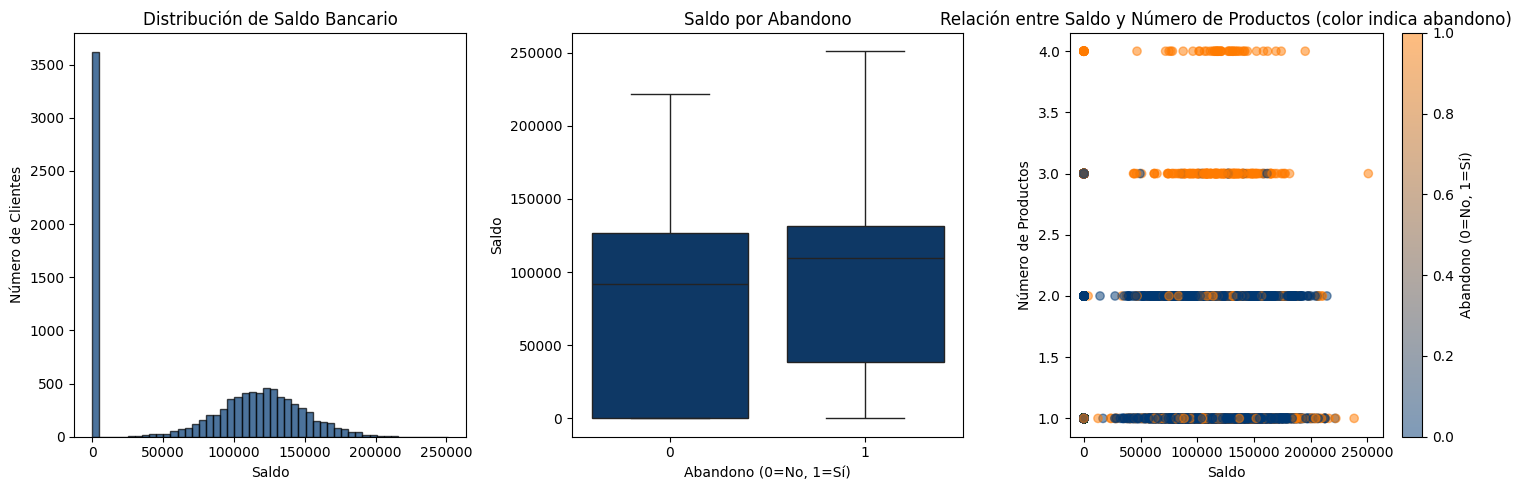

Estadísticas de saldo:
  Saldo promedio de clientes que se quedaron: 72,745.30
  Saldo promedio de clientes que abandonaron: 91,108.54


In [334]:
# Análisis por saldo bancario
plt.figure(figsize=(15, 5))

# Histograma de saldo
plt.subplot(1, 3, 1)
plt.hist(clients_df['Balance'], bins=50, color=palette_colors[0], edgecolor='black', alpha=0.7)
plt.title('Distribución de Saldo Bancario')
plt.xlabel('Saldo')
plt.ylabel('Número de Clientes')

# Boxplot de saldo por abandono
plt.subplot(1, 3, 2)
sns.boxplot(data=clients_df, x='Exited', y='Balance')
plt.title('Saldo por Abandono')
plt.xlabel('Abandono (0=No, 1=Sí)')
plt.ylabel('Saldo')

# Relación entre saldo y número de productos
plt.subplot(1, 3, 3)

# Crear un colormap personalizado con AZUL_3 y NARANJA_3
from matplotlib.colors import LinearSegmentedColormap
custom_cmap = LinearSegmentedColormap.from_list("custom_churn", [AZUL_3, NARANJA_3])

plt.scatter(clients_df['Balance'], clients_df['NumOfProducts'], alpha=0.5, c=clients_df['Exited'], cmap=custom_cmap)
plt.title('Relación entre Saldo y Número de Productos (color indica abandono)')
plt.xlabel('Saldo')
plt.ylabel('Número de Productos')
plt.colorbar(label='Abandono (0=No, 1=Sí)')

plt.tight_layout()
plt.show()

print(f"Estadísticas de saldo:")
print(f"  Saldo promedio de clientes que se quedaron: {clients_df[clients_df['Exited']==0]['Balance'].mean():,.2f}")
print(f"  Saldo promedio de clientes que abandonaron: {clients_df[clients_df['Exited']==1]['Balance'].mean():,.2f}")

## <font color="#ff743d">**Análisis de Transacciones**:

**Objetivo**: Caracterizar los patrones de transacción y su posible relación con el churn.

**Hallazgos Clave**: Se analizaron la distribución de tipos de transacción (ej. TRANSFER, PAYMENT, DEBIT, CASH_OUT, CASH_IN), el monto promedio por tipo y la frecuencia de transacciones por cliente. Estas métricas ayudan a comprender la actividad financiera del cliente.

**Visualizaciones Relevantes**: Gráfico de pastel (`plt.pie`) de tipos de transacción, gráfico de barras del monto promedio por tipo de transacción (`plt.bar`) y histograma del número de transacciones por cliente (`plt.hist`).

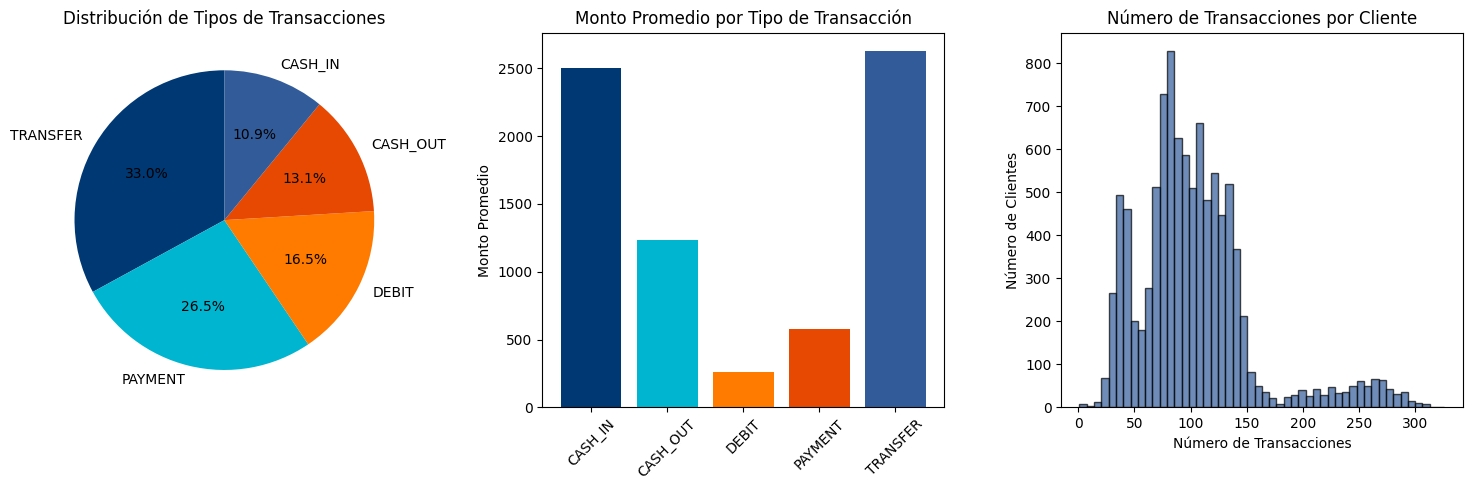

Estadísticas de transacciones:
  Total de transacciones: 1022383
  Monto total de transacciones: 1,530,408,817.84
  Monto promedio por transacción: 1,496.90


In [335]:
# Análisis de tipos de transacciones
plt.figure(figsize=(15, 5))

# Distribución de tipos de transacciones
plt.subplot(1, 3, 1)
transaction_types = transactions_df['TransactionType'].value_counts()
plt.pie(transaction_types.values, labels=transaction_types.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribución de Tipos de Transacciones')

# Monto promedio por tipo de transacción
plt.subplot(1, 3, 2)
avg_amount_by_type = transactions_df.groupby('TransactionType')['Amount'].mean()
plt.bar(avg_amount_by_type.index, avg_amount_by_type.values, color=palette_colors[:5])
plt.title('Monto Promedio por Tipo de Transacción')
plt.ylabel('Monto Promedio')
plt.xticks(rotation=45)

# Número de transacciones por cliente
plt.subplot(1, 3, 3)
transactions_per_customer = transactions_df.groupby('CustomerId').size()
plt.hist(transactions_per_customer, bins=50, color=palette_colors[4], edgecolor='black', alpha=0.7)
plt.title('Número de Transacciones por Cliente')
plt.xlabel('Número de Transacciones')
plt.ylabel('Número de Clientes')

plt.tight_layout()
plt.show()

print(f"Estadísticas de transacciones:")
print(f"  Total de transacciones: {len(transactions_df)}")
print(f"  Monto total de transacciones: {transactions_df['Amount'].sum():,.2f}")
print(f"  Monto promedio por transacción: {transactions_df['Amount'].mean():,.2f}")

## <font color="#ff743d">**Análisis de Sesiones de Aplicación**:

**Objetivo**: Investigar el comportamiento de los clientes en la aplicación móvil y su impacto en el churn.

**Hallazgos Clave**: Se evaluó la duración de las sesiones, el uso de funcionalidades específicas (transferencias, pagos, inversiones, notificaciones push) y la tasa de inicios de sesión fallidos. Un menor uso o un aumento en los fallos de inicio de sesión podrían ser indicadores de insatisfacción o desinterés.

**Visualizaciones Relevantes**: Histograma de duración de sesiones (`plt.hist`), gráfico de barras del uso de funcionalidades (`plt.bar`), gráfico de barras de la tasa de inicio de sesión fallido (`plt.bar`) y diagramas de caja (`sns.boxplot`) mostrando la duración de la sesión por uso de funcionalidades.

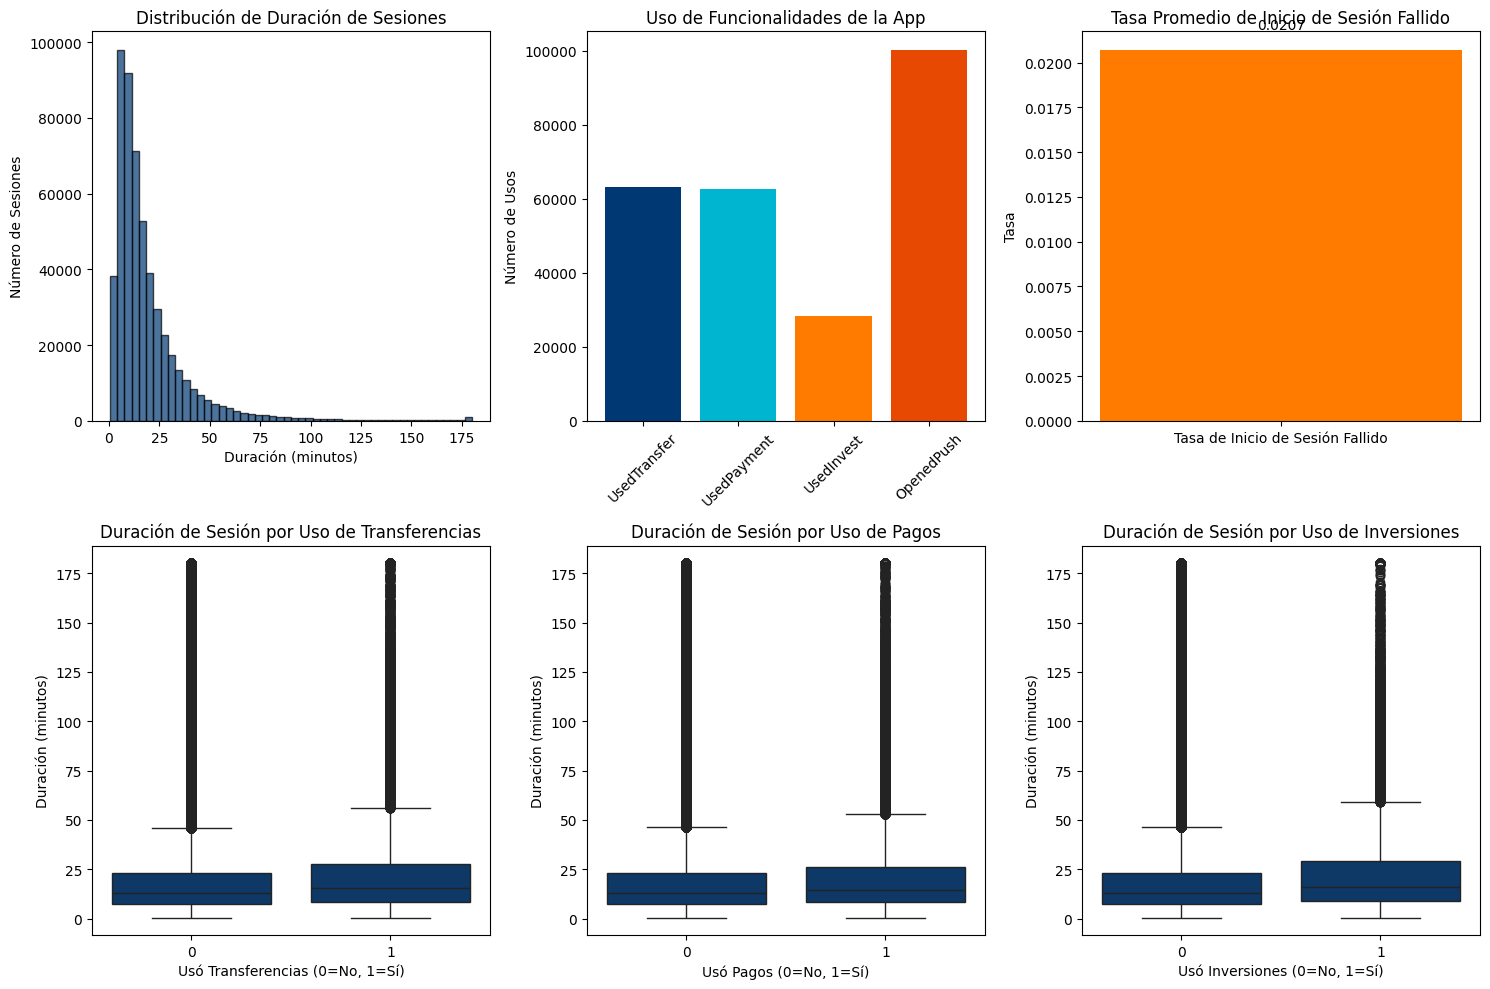

Estadísticas de sesiones de app:
  Total de sesiones: 537697
  Duración promedio de sesión: 19.30 minutos
  Porcentaje de sesiones que usaron transferencias: 11.75%
  Porcentaje de sesiones que usaron pagos: 11.66%
  Porcentaje de sesiones que usaron inversiones: 5.26%


In [336]:
# Análisis de sesiones de aplicación
plt.figure(figsize=(15, 10))

# Duración promedio de sesiones
plt.subplot(2, 3, 1)
plt.hist(app_sessions_df['DurationMin'], bins=50, color=palette_colors[0], edgecolor='black', alpha=0.7)
plt.title('Distribución de Duración de Sesiones')
plt.xlabel('Duración (minutos)')
plt.ylabel('Número de Sesiones')

# Uso de funcionalidades
plt.subplot(2, 3, 2)
features = ['UsedTransfer', 'UsedPayment', 'UsedInvest', 'OpenedPush']
feature_usage = [app_sessions_df[col].sum() for col in features]
plt.bar(features, feature_usage, color=palette_colors[:4])
plt.title('Uso de Funcionalidades de la App')
plt.ylabel('Número de Usos')
plt.xticks(rotation=45)

# Tasa de inicio de sesión fallido
plt.subplot(2, 3, 3)
failed_login_rate = app_sessions_df['FailedLogin'].mean()
plt.bar(['Tasa de Inicio de Sesión Fallido'], [failed_login_rate], color=palette_colors[2])
plt.title('Tasa Promedio de Inicio de Sesión Fallido')
plt.ylabel('Tasa')
plt.text(0, failed_login_rate + 0.001, f'{failed_login_rate:.4f}', ha='center', va='bottom')

# Distribución de duración por funcionalidad usada
plt.subplot(2, 3, 4)
sns.boxplot(data=app_sessions_df, y='DurationMin', x='UsedTransfer')
plt.title('Duración de Sesión por Uso de Transferencias')
plt.xlabel('Usó Transferencias (0=No, 1=Sí)')
plt.ylabel('Duración (minutos)')

plt.subplot(2, 3, 5)
sns.boxplot(data=app_sessions_df, y='DurationMin', x='UsedPayment')
plt.title('Duración de Sesión por Uso de Pagos')
plt.xlabel('Usó Pagos (0=No, 1=Sí)')
plt.ylabel('Duración (minutos)')

plt.subplot(2, 3, 6)
sns.boxplot(data=app_sessions_df, y='DurationMin', x='UsedInvest')
plt.title('Duración de Sesión por Uso de Inversiones')
plt.xlabel('Usó Inversiones (0=No, 1=Sí)')
plt.ylabel('Duración (minutos)')

plt.tight_layout()
plt.show()

print(f"Estadísticas de sesiones de app:")
print(f"  Total de sesiones: {len(app_sessions_df)}")
print(f"  Duración promedio de sesión: {app_sessions_df['DurationMin'].mean():.2f} minutos")
print(f"  Porcentaje de sesiones que usaron transferencias: {app_sessions_df['UsedTransfer'].mean()*100:.2f}%")
print(f"  Porcentaje de sesiones que usaron pagos: {app_sessions_df['UsedPayment'].mean()*100:.2f}%")
print(f"  Porcentaje de sesiones que usaron inversiones: {app_sessions_df['UsedInvest'].mean()*100:.2f}%")

## <font color="#ff743d">**Conversión de Columnas de Fecha**</font>

In [337]:
# Convertir columnas de fecha
clients_df['ExitDate'] = pd.to_datetime(clients_df['ExitDate'], errors='coerce')
transactions_df['TransactionDate'] = pd.to_datetime(transactions_df['TransactionDate'], errors='coerce')
app_sessions_df['SessionDate'] = pd.to_datetime(app_sessions_df['SessionDate'], errors='coerce')

print("Columnas de fecha convertidas")

Columnas de fecha convertidas


## <font color="#ff743d">**Identificación y Corrección de Fugas de Datos**</font>

Es crucial eliminar cualquier información que esté disponible después de la fecha de abandono para clientes que abandonaron, ya que en la vida real no tendríamos acceso a esta información al momento de hacer predicciones.

In [338]:
# Auditoría de fugas de datos y limpieza
exited_clients_with_date = clients_df[(clients_df['Exited'] == 1) & (clients_df['ExitDate'].notna())]

# Procesar transacciones
transactions_merged = transactions_df.merge(
    exited_clients_with_date[['CustomerId', 'ExitDate']],
    on='CustomerId',
    how='inner'
)
transactions_to_remove = transactions_merged[
    transactions_merged['TransactionDate'] > transactions_merged['ExitDate']
]
num_transactions_removed = len(transactions_to_remove)

transactions_df_cleaned = transactions_df.merge(
    transactions_to_remove[['TransactionId']],
    on='TransactionId',
    how='left',
    indicator=True
).query('_merge == "left_only"').drop(columns=['_merge'])
transactions_df = transactions_df_cleaned.copy()

# Procesar sesiones de aplicación
app_sessions_merged = app_sessions_df.merge(
    exited_clients_with_date[['CustomerId', 'ExitDate']],
    on='CustomerId',
    how='inner'
)
app_sessions_to_remove = app_sessions_merged[
    app_sessions_merged['SessionDate'] > app_sessions_merged['ExitDate']
]
num_app_sessions_removed = len(app_sessions_to_remove)

app_sessions_df_cleaned = app_sessions_df.merge(
    app_sessions_to_remove[['SessionId']],
    on='SessionId',
    how='left',
    indicator=True
).query('_merge == "left_only"').drop(columns=['_merge'])
app_sessions_df = app_sessions_df_cleaned.copy()

print(f"Número de transacciones eliminadas después de la ExitDate: {num_transactions_removed}")
print(f"Número de sesiones de aplicación eliminadas después de la ExitDate: {num_app_sessions_removed}")

Número de transacciones eliminadas después de la ExitDate: 0
Número de sesiones de aplicación eliminadas después de la ExitDate: 0


In [342]:
CUTOFF_DATE = transactions_df['TransactionDate'].max() - pd.Timedelta(days=90)

# Renombrar los DataFrames para que coincidan con la sección de Feature Engineering
df_clients = clients_df.copy()
df_tx = transactions_df.copy()
df_ss = app_sessions_df.copy()

# Convertir columnas de fecha a datetime para Feature Engineering
df_clients['ExitDate'] = pd.to_datetime(df_clients['ExitDate'], errors='coerce')
df_tx['TransactionDate'] = pd.to_datetime(df_tx['TransactionDate'], errors='coerce')
df_ss['SessionDate'] = pd.to_datetime(df_ss['SessionDate'], errors='coerce')

print(f"CUTOFF_DATE establecida en: {CUTOFF_DATE}")
print("DataFrames renombrados y columnas de fecha convertidas para Feature Engineering.")

CUTOFF_DATE establecida en: 2025-07-02 00:00:00
DataFrames renombrados y columnas de fecha convertidas para Feature Engineering.


## <font color="#ff743d">**Feature Engineering**</font>

En esta etapa, se crearon características temporales y de comportamiento para enriquecer los datos de los clientes y capturar patrones que pudieran predecir el churn.

*   **Definición de Ventanas de Tiempo**: Se establecieron ventanas de observación (`WINDOW_1`, `WINDOW_2`, `WINDOW_3`) y una ventana de churn (`CUTOFF_DATE` hasta `2025-09-30`) para analizar el comportamiento del cliente en diferentes periodos.
*   **Características de Transacciones**:
    *   `avg_tx_amount`, `std_tx_amount`, `total_tx`: Métricas agregadas de monto y frecuencia de transacciones.
    *   `days_since_last_tx`: Recencia de la última transacción.
    *   `tx_q1q2_rate_of_change`, `tx_q2q3_rate_of_change`: Tasas de cambio en el volumen de transacciones entre periodos para identificar tendencias de actividad decreciente.
*   **Características de Interacción con la App**:
    *   `avg_ss_duration`, `std_ss_duration`, `total_ss`: Duración promedio, desviación estándar y total de sesiones.
    *   `days_since_last_ss`: Recencia de la última sesión.
    *   `ss_q1q2_rate_of_change`, `ss_q2q3_rate_of_change`: Tasas de cambio en el volumen de sesiones de aplicación.
    *   `failed_ratio_q1`, `failed_ratio_q2`, `failed_ratio_q3`: Proporción de inicios de sesión fallidos por periodo.
    *   `failed_ratio_spike_q2`, `failed_ratio_spike_q3`: Cambios abruptos en la tasa de inicios de sesión fallidos.
    *   `failed_ratio_volatility`: Volatilidad en la tasa de inicios de sesión fallidos.
*   **Gestión de Fugas de Datos y Multicolinealidad**: Se realizó una limpieza rigurosa de datos para evitar fugas y se aplicó el Factor de Inflación de la Varianza (VIF) para identificar y mitigar problemas de multicolinealidad entre las características.

### <font color="#ffbf80">**Conclusiones y Mejoras**</font>

*   **Análisis de Fugas de Datos y Multicolinealidad**: Se abordaron y corrigieron problemas críticos de fuga de datos en las fases iniciales del procesamiento, asegurando que el modelo predictivo se base únicamente en información disponible antes del evento de abandono. Además, se realizó un análisis de VIF para identificar y eliminar características altamente correlacionadas, mejorando la estabilidad y la interpretabilidad del modelo.
*   **Resumen Visual de los Hallazgos**: Las visualizaciones a lo largo del notebook ofrecen una comprensión clara de los factores que influyen en el churn, desde características demográficas y geográficas hasta patrones de transacción y comportamiento en la aplicación. Estos hallazgos son fundamentales para diseñar estrategias de retención de clientes efectivas.

## <font color="#ff743d">**Datasets Integration**</font>

In [343]:
df_tx['TransactionDate'].max(), df_ss['SessionDate'].max()

(Timestamp('2025-09-30 00:00:00'), Timestamp('2025-09-30 00:00:00'))

A partir de los descubrimientos de la etapa de **Exploratory Data Analysis**, se buscará crear features para llevar las series temporales a un formato tabular y que de esta manera permitan captar patrones para predecir el Churn de clientes.

Para esto, se tomará un período de tiempo de análisis de 1 año, en busca de predecir el **Churn** dentro de los últimos **3 meses *(Ventana de Churn)***. Utilizando la fecha de corte previamente definida:

* `CUTOFF_DATE = '2025-10-02'` hasta `'2025-12-31'`-> Ventana de Churn (Ventana Objetivo)

Luego, se buscará analizar el comportamiento del cliente en distintas ventanas de tiempo con el objetivo de generar indicadores que permitan prevenir de forma temprana la probabilidad de abandono y poder tomar acciones preventivas.

* `WINDOW_1_START = 2024-12-31'`
* `WINDOW_1_END = '2025-04-05'`
* `WINDOW_2_START = '2025-04-05'`
* `WINDOW_2_END = '2025-07-04'`
* `WINDOW_3_START = '2025-07-04'`
* `WINDOW_3_END = CUTOFF_DATE`

### **Nota:**

Siempre se tomará:

* Inicio de fechas: `Periodo a observar >= Fecha Inicio`
* Final de fechas: `Periodo a observar < Fecha Fin`

In [344]:
WINDOW_1_START = CUTOFF_DATE - pd.Timedelta(days=275)
WINDOW_1_START

Timestamp('2024-09-30 00:00:00')

In [345]:
WINDOW_1_END = CUTOFF_DATE - pd.Timedelta(days=180)
WINDOW_1_END

Timestamp('2025-01-03 00:00:00')

In [346]:
WINDOW_2_START = WINDOW_1_END

In [347]:
WINDOW_2_END = CUTOFF_DATE - pd.Timedelta(days=90)
WINDOW_2_END

Timestamp('2025-04-03 00:00:00')

In [348]:
WINDOW_3_START = WINDOW_2_END

## <font color="#ff743d">**Transactions**</font>

In [349]:
df_tx_filtered = df_tx[(df_tx['TransactionDate'] >= WINDOW_1_START) & (df_tx['TransactionDate'] < CUTOFF_DATE)]

In [350]:
# Crea un DataFrame para los features
features_tx = df_tx_filtered.groupby('CustomerId').agg(
    avg_tx_amount=('Amount', 'mean'),
    std_tx_amount=('Amount', 'std'),
    total_tx=('Amount', 'count'),
    last_tx_date=('TransactionDate', 'max')
).reset_index()

In [351]:
features_tx

,CustomerId,avg_tx_amount,std_tx_amount,total_tx,last_tx_date
0,15565701,1046.275325,625.268237,77,2025-06-30
1,15565706,369.380000,345.435777,5,2024-12-13
2,15565714,733.938659,488.882252,82,2025-06-27
3,15565779,2013.207170,1553.526599,53,2025-06-30
4,15565796,505.739681,331.612091,94,2025-07-01
...,...,...,...,...,...
9923,15815628,983.848333,691.791799,48,2025-06-27
9924,15815645,5063.359173,3156.953055,133,2025-06-29
9925,15815656,5630.768466,3580.088879,189,2025-06-28
9926,15815660,670.051591,577.347014,44,2025-06-29


In [352]:
features_tx['days_since_last_tx'] = (CUTOFF_DATE - features_tx['last_tx_date']).dt.days

In [353]:
txs_q1 = df_tx_filtered[(df_tx_filtered['TransactionDate'] >= WINDOW_1_START) & (df_tx_filtered['TransactionDate'] < WINDOW_1_END)]
txs_q2 = df_tx_filtered[(df_tx_filtered['TransactionDate'] >= WINDOW_2_START) & (df_tx_filtered['TransactionDate'] < WINDOW_2_END)]
txs_q3 = df_tx_filtered[(df_tx_filtered['TransactionDate'] >= WINDOW_3_START) & (df_tx_filtered['TransactionDate'] < CUTOFF_DATE)]

In [354]:
total_tx_q1 = txs_q1.groupby('CustomerId').size().reset_index(name='total_tx_q1')
total_tx_q2 = txs_q2.groupby('CustomerId').size().reset_index(name='total_tx_q2')
total_tx_q3 = txs_q3.groupby('CustomerId').size().reset_index(name='total_tx_q3')

In [355]:
features_tx = features_tx.merge(total_tx_q1, on='CustomerId', how='left')
features_tx = features_tx.merge(total_tx_q2, on='CustomerId', how='left')
features_tx = features_tx.merge(total_tx_q3, on='CustomerId', how='left')

total_tx_cols = ['total_tx_q1', 'total_tx_q2', 'total_tx_q3']
features_tx[total_tx_cols] = features_tx[total_tx_cols].fillna(0)

In [356]:
features_tx

,CustomerId,avg_tx_amount,std_tx_amount,total_tx,last_tx_date,days_since_last_tx,total_tx_q1,total_tx_q2,total_tx_q3
0,15565701,1046.275325,625.268237,77,2025-06-30,2,25.0,29.0,23.0
1,15565706,369.380000,345.435777,5,2024-12-13,201,5.0,0.0,0.0
2,15565714,733.938659,488.882252,82,2025-06-27,5,28.0,33.0,21.0
3,15565779,2013.207170,1553.526599,53,2025-06-30,2,24.0,11.0,18.0
4,15565796,505.739681,331.612091,94,2025-07-01,1,33.0,24.0,37.0
...,...,...,...,...,...,...,...,...,...
9923,15815628,983.848333,691.791799,48,2025-06-27,5,16.0,13.0,19.0
9924,15815645,5063.359173,3156.953055,133,2025-06-29,3,1.0,73.0,59.0
9925,15815656,5630.768466,3580.088879,189,2025-06-28,4,76.0,64.0,49.0
9926,15815660,670.051591,577.347014,44,2025-06-29,3,18.0,14.0,12.0


In [357]:
df_clients['CustomerId'].nunique()

10000

In [358]:
uniques = features_tx['CustomerId'].unique()

In [359]:
features_tx['tx_q1q2_rate_of_change'] = (features_tx['total_tx_q2'] - features_tx['total_tx_q1']) / (features_tx['total_tx_q1'] + 1)
features_tx['tx_q2q3_rate_of_change'] = (features_tx['total_tx_q3'] - features_tx['total_tx_q2']) / (features_tx['total_tx_q2'] + 1)

In [360]:
features_tx

,CustomerId,avg_tx_amount,std_tx_amount,total_tx,last_tx_date,days_since_last_tx,total_tx_q1,total_tx_q2,total_tx_q3,tx_q1q2_rate_of_change,tx_q2q3_rate_of_change
0,15565701,1046.275325,625.268237,77,2025-06-30,2,25.0,29.0,23.0,0.153846,-0.200000
1,15565706,369.380000,345.435777,5,2024-12-13,201,5.0,0.0,0.0,-0.833333,0.000000
2,15565714,733.938659,488.882252,82,2025-06-27,5,28.0,33.0,21.0,0.172414,-0.352941
3,15565779,2013.207170,1553.526599,53,2025-06-30,2,24.0,11.0,18.0,-0.520000,0.583333
4,15565796,505.739681,331.612091,94,2025-07-01,1,33.0,24.0,37.0,-0.264706,0.520000
...,...,...,...,...,...,...,...,...,...,...,...
9923,15815628,983.848333,691.791799,48,2025-06-27,5,16.0,13.0,19.0,-0.176471,0.428571
9924,15815645,5063.359173,3156.953055,133,2025-06-29,3,1.0,73.0,59.0,36.000000,-0.189189
9925,15815656,5630.768466,3580.088879,189,2025-06-28,4,76.0,64.0,49.0,-0.155844,-0.230769
9926,15815660,670.051591,577.347014,44,2025-06-29,3,18.0,14.0,12.0,-0.210526,-0.133333


In [361]:
features_tx.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9928 entries, 0 to 9927
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   CustomerId              9928 non-null   int64         
 1   avg_tx_amount           9928 non-null   float64       
 2   std_tx_amount           9927 non-null   float64       
 3   total_tx                9928 non-null   int64         
 4   last_tx_date            9928 non-null   datetime64[ns]
 5   days_since_last_tx      9928 non-null   int64         
 6   total_tx_q1             9928 non-null   float64       
 7   total_tx_q2             9928 non-null   float64       
 8   total_tx_q3             9928 non-null   float64       
 9   tx_q1q2_rate_of_change  9928 non-null   float64       
 10  tx_q2q3_rate_of_change  9928 non-null   float64       
dtypes: datetime64[ns](1), float64(7), int64(3)
memory usage: 853.3 KB


In [362]:
features_tx[features_tx['std_tx_amount'].isna()]

,CustomerId,avg_tx_amount,std_tx_amount,total_tx,last_tx_date,days_since_last_tx,total_tx_q1,total_tx_q2,total_tx_q3,tx_q1q2_rate_of_change,tx_q2q3_rate_of_change
8079,15769353,2903.93,NaN,1,2024-09-30,275,1.0,0.0,0.0,-0.5,0.0


In [363]:
features_tx['std_tx_amount'] = features_tx['std_tx_amount'].fillna(0)

In [364]:
(features_tx['total_tx_q3'] == 0).sum()

np.int64(40)

In [365]:
df_clients_filtered = df_clients[df_clients['CustomerId'].isin(uniques)].copy()

In [366]:
consolidated_ds = df_clients_filtered.merge(features_tx, on='CustomerId')

In [367]:
consolidated_ds

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,...,avg_tx_amount,std_tx_amount,total_tx,last_tx_date,days_since_last_tx,total_tx_q1,total_tx_q2,total_tx_q3,tx_q1q2_rate_of_change,tx_q2q3_rate_of_change
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,...,1202.152727,1034.867626,44,2025-06-17,15,15.0,16.0,13.0,0.062500,-0.176471
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,...,792.165135,570.482888,111,2025-07-01,1,36.0,34.0,41.0,-0.054054,0.200000
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,...,3182.708551,2074.604122,207,2025-06-30,2,78.0,72.0,57.0,-0.075949,-0.205479
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,...,350.445926,269.538142,27,2025-06-18,14,10.0,8.0,9.0,-0.181818,0.111111
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,...,563.445600,407.555125,100,2025-06-28,4,36.0,23.0,41.0,-0.351351,0.750000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9923,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,...,1126.719661,963.321738,59,2025-06-29,3,21.0,19.0,19.0,-0.090909,0.000000
9924,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,...,1240.056712,697.282220,73,2025-06-29,3,35.0,18.0,20.0,-0.472222,0.105263
9925,9998,15584532,Liu,709,France,Female,36,7,0.00,1,...,147.037308,109.339220,26,2025-06-19,13,14.0,7.0,5.0,-0.466667,-0.250000
9926,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,...,573.957846,456.848268,65,2025-06-23,9,24.0,24.0,17.0,0.000000,-0.280000


## <font color="#ff743d">**App Interaction**</font>

In [368]:
df_ss_filtered = df_ss[(df_ss['SessionDate'] >= WINDOW_1_START) & (df_ss['SessionDate'] < CUTOFF_DATE)]

In [369]:
# Crea un DataFrame para los features
features_ss = df_ss_filtered.groupby('CustomerId').agg(
    avg_ss_duration=('DurationMin', 'mean'),
    std_ss_duration=('DurationMin', 'std'),
    total_ss=('DurationMin', 'count'),
    last_ss_date=('SessionDate', 'max')
).reset_index()

In [370]:
features_ss['days_since_last_ss'] = (CUTOFF_DATE - features_ss['last_ss_date']).dt.days

In [371]:
ss_q1 = df_ss_filtered[(df_ss_filtered['SessionDate'] >= WINDOW_1_START) & (df_ss_filtered['SessionDate'] < WINDOW_1_END)]
ss_q2 = df_ss_filtered[(df_ss_filtered['SessionDate'] >= WINDOW_2_START) & (df_ss_filtered['SessionDate'] < WINDOW_2_END)]
ss_q3 = df_ss_filtered[(df_ss_filtered['SessionDate'] >= WINDOW_3_START) & (df_ss_filtered['SessionDate'] < CUTOFF_DATE)]


total_ss_q1 = ss_q1.groupby('CustomerId').size().reset_index(name='total_ss_q1')
total_ss_q2 = ss_q2.groupby('CustomerId').size().reset_index(name='total_ss_q2')
total_ss_q3 = ss_q3.groupby('CustomerId').size().reset_index(name='total_ss_q3')

total_failed_ss_q1 = ss_q1.groupby('CustomerId')['FailedLogin'].sum().reset_index(name='total_failed_ss_q1')
total_failed_ss_q2 = ss_q2.groupby('CustomerId')['FailedLogin'].sum().reset_index(name='total_failed_ss_q2')
total_failed_ss_q3 = ss_q3.groupby('CustomerId')['FailedLogin'].sum().reset_index(name='total_failed_ss_q3')

In [372]:
features_ss

,CustomerId,avg_ss_duration,std_ss_duration,total_ss,last_ss_date,days_since_last_ss
0,15565701,20.193141,16.967688,48,2025-06-28,4
1,15565706,8.954095,4.619341,4,2025-01-29,154
2,15565714,22.648889,22.856120,29,2025-06-21,11
3,15565779,10.578942,8.611897,38,2025-06-27,5
4,15565796,20.035281,15.648206,38,2025-07-01,1
...,...,...,...,...,...,...
9924,15815628,14.973594,21.559310,42,2025-06-24,8
9925,15815645,31.075120,31.221324,108,2025-06-28,4
9926,15815656,27.701721,22.465682,111,2025-06-30,2
9927,15815660,12.597343,9.886917,43,2025-05-27,36


In [373]:
features_ss = features_ss.merge(total_ss_q1, on='CustomerId')
features_ss = features_ss.merge(total_ss_q2, on='CustomerId')
features_ss = features_ss.merge(total_ss_q3, on='CustomerId')
features_ss = features_ss.merge(total_failed_ss_q1, on='CustomerId')
features_ss = features_ss.merge(total_failed_ss_q2, on='CustomerId')
features_ss = features_ss.merge(total_failed_ss_q3, on='CustomerId')

In [374]:
features_ss

,CustomerId,avg_ss_duration,std_ss_duration,total_ss,last_ss_date,days_since_last_ss,total_ss_q1,total_ss_q2,total_ss_q3,total_failed_ss_q1,total_failed_ss_q2,total_failed_ss_q3
0,15565701,20.193141,16.967688,48,2025-06-28,4,14,13,21,1,1,0
1,15565714,22.648889,22.856120,29,2025-06-21,11,10,11,8,0,0,1
2,15565779,10.578942,8.611897,38,2025-06-27,5,12,15,11,1,1,0
3,15565796,20.035281,15.648206,38,2025-07-01,1,1,25,12,1,1,0
4,15565806,15.455864,12.302715,37,2025-07-01,1,11,17,9,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9710,15815628,14.973594,21.559310,42,2025-06-24,8,14,18,10,0,1,0
9711,15815645,31.075120,31.221324,108,2025-06-28,4,41,37,30,0,1,1
9712,15815656,27.701721,22.465682,111,2025-06-30,2,28,34,49,0,0,0
9713,15815660,12.597343,9.886917,43,2025-05-27,36,17,15,11,0,1,0


In [375]:
def calculate_change_rate(row, previous_q, followed_q):
    freq_past = row[previous_q]
    freq_last = row[followed_q]

    if freq_past == 0:
        if freq_last > 0:
            return 1.0
        else:
            return 0.0
    else:
        return (freq_last - freq_past) / freq_past

In [376]:
features_ss['ss_q1q2_rate_of_change'] = features_ss.apply(
                                            lambda row: calculate_change_rate(row, 'total_ss_q1', 'total_ss_q2'),
                                            axis=1)

features_ss['ss_q2q3_rate_of_change'] = features_ss.apply(
                                            lambda row: calculate_change_rate(row, 'total_ss_q2', 'total_ss_q3'),
                                            axis=1)

In [377]:
def safe_division(numerator, denominator):
    return numerator / denominator if denominator > 0 else 0.0

features_ss['failed_ratio_q1'] = features_ss.apply(
    lambda row: safe_division(row['total_failed_ss_q1'], row['total_ss_q1']), axis=1
)
features_ss['failed_ratio_q2'] = features_ss.apply(
    lambda row: safe_division(row['total_failed_ss_q2'], row['total_ss_q2']), axis=1
)
features_ss['failed_ratio_q3'] = features_ss.apply(
    lambda row: safe_division(row['total_failed_ss_q3'], row['total_ss_q3']), axis=1
)

In [378]:
# Diferencia entre el ratio del último período y el anterior
features_ss['failed_ratio_spike_q2'] = features_ss['failed_ratio_q2'] - features_ss['failed_ratio_q1']
features_ss['failed_ratio_spike_q3'] = features_ss['failed_ratio_q3'] - features_ss['failed_ratio_q2']

In [379]:
# Selecciona las columnas de ratio
ratio_cols = ['failed_ratio_q1', 'failed_ratio_q2', 'failed_ratio_q3']

# Calcula la desviación estándar para cada fila (axis=1)
features_ss['failed_ratio_volatility'] = features_ss[ratio_cols].std(axis=1)

In [380]:
features_ss

,CustomerId,avg_ss_duration,std_ss_duration,total_ss,last_ss_date,days_since_last_ss,total_ss_q1,total_ss_q2,total_ss_q3,total_failed_ss_q1,total_failed_ss_q2,total_failed_ss_q3,ss_q1q2_rate_of_change,ss_q2q3_rate_of_change,failed_ratio_q1,failed_ratio_q2,failed_ratio_q3,failed_ratio_spike_q2,failed_ratio_spike_q3,failed_ratio_volatility
0,15565701,20.193141,16.967688,48,2025-06-28,4,14,13,21,1,1,0,-0.071429,0.615385,0.071429,0.076923,0.000000,0.005495,-0.076923,0.042913
1,15565714,22.648889,22.856120,29,2025-06-21,11,10,11,8,0,0,1,0.100000,-0.272727,0.000000,0.000000,0.125000,0.000000,0.125000,0.072169
2,15565779,10.578942,8.611897,38,2025-06-27,5,12,15,11,1,1,0,0.250000,-0.266667,0.083333,0.066667,0.000000,-0.016667,-0.066667,0.044096
3,15565796,20.035281,15.648206,38,2025-07-01,1,1,25,12,1,1,0,24.000000,-0.520000,1.000000,0.040000,0.000000,-0.960000,-0.040000,0.566157
4,15565806,15.455864,12.302715,37,2025-07-01,1,11,17,9,0,1,0,0.545455,-0.470588,0.000000,0.058824,0.000000,0.058824,-0.058824,0.033962
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9710,15815628,14.973594,21.559310,42,2025-06-24,8,14,18,10,0,1,0,0.285714,-0.444444,0.000000,0.055556,0.000000,0.055556,-0.055556,0.032075
9711,15815645,31.075120,31.221324,108,2025-06-28,4,41,37,30,0,1,1,-0.097561,-0.189189,0.000000,0.027027,0.033333,0.027027,0.006306,0.017708
9712,15815656,27.701721,22.465682,111,2025-06-30,2,28,34,49,0,0,0,0.214286,0.441176,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9713,15815660,12.597343,9.886917,43,2025-05-27,36,17,15,11,0,1,0,-0.117647,-0.266667,0.000000,0.066667,0.000000,0.066667,-0.066667,0.038490


In [381]:
uniques = features_ss['CustomerId'].unique()

In [382]:
consolidated_ds = consolidated_ds[consolidated_ds['CustomerId'].isin(uniques)].copy()

In [383]:
consolidated_ds = consolidated_ds.merge(features_ss, on='CustomerId')

In [384]:
consolidated_ds

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,...,total_failed_ss_q2,total_failed_ss_q3,ss_q1q2_rate_of_change,ss_q2q3_rate_of_change,failed_ratio_q1,failed_ratio_q2,failed_ratio_q3,failed_ratio_spike_q2,failed_ratio_spike_q3,failed_ratio_volatility
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,...,0,0,0.571429,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,...,0,0,-0.500000,0.571429,0.000000,0.0,0.0,0.000000,0.0,0.000000
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,...,0,0,-0.372093,-0.407407,0.023256,0.0,0.0,-0.023256,0.0,0.013427
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,...,0,0,-0.428571,0.500000,0.000000,0.0,0.0,0.000000,0.0,0.000000
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,...,0,0,0.300000,-0.461538,0.100000,0.0,0.0,-0.100000,0.0,0.057735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9710,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,...,0,0,1.750000,0.272727,0.000000,0.0,0.0,0.000000,0.0,0.000000
9711,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,...,0,0,0.000000,3.250000,0.000000,0.0,0.0,0.000000,0.0,0.000000
9712,9998,15584532,Liu,709,France,Female,36,7,0.00,1,...,0,0,-0.700000,2.666667,0.100000,0.0,0.0,-0.100000,0.0,0.057735
9713,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,...,0,0,-0.368421,-0.833333,0.052632,0.0,0.0,-0.052632,0.0,0.030387


In [385]:
consolidated_ds.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'ExitDate',
       'CustomerSegment', 'AgeGroup', 'avg_tx_amount', 'std_tx_amount',
       'total_tx', 'last_tx_date', 'days_since_last_tx', 'total_tx_q1',
       'total_tx_q2', 'total_tx_q3', 'tx_q1q2_rate_of_change',
       'tx_q2q3_rate_of_change', 'avg_ss_duration', 'std_ss_duration',
       'total_ss', 'last_ss_date', 'days_since_last_ss', 'total_ss_q1',
       'total_ss_q2', 'total_ss_q3', 'total_failed_ss_q1',
       'total_failed_ss_q2', 'total_failed_ss_q3', 'ss_q1q2_rate_of_change',
       'ss_q2q3_rate_of_change', 'failed_ratio_q1', 'failed_ratio_q2',
       'failed_ratio_q3', 'failed_ratio_spike_q2', 'failed_ratio_spike_q3',
       'failed_ratio_volatility'],
      dtype='object')

In [386]:
consolidated_ds.drop(['CustomerSegment',
                      'total_tx_q1', 'total_tx_q2', 'total_tx_q3','total_ss_q1', 'total_ss_q2', 'total_ss_q3', 'failed_ratio_q1',
                      'total_failed_ss_q1', 'total_failed_ss_q2', 'total_failed_ss_q3',
                      'failed_ratio_q2', 'failed_ratio_q3', 'last_tx_date', 'last_ss_date', 'total_tx','total_ss'],
                     axis=1,
                     inplace=True)

In [387]:
consolidated_ds = consolidated_ds[(consolidated_ds['ExitDate'] > CUTOFF_DATE) | (consolidated_ds['ExitDate'].isnull())]

In [388]:
ds_features_eng = consolidated_ds.copy()

In [389]:
ds_features_eng

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,...,tx_q1q2_rate_of_change,tx_q2q3_rate_of_change,avg_ss_duration,std_ss_duration,days_since_last_ss,ss_q1q2_rate_of_change,ss_q2q3_rate_of_change,failed_ratio_spike_q2,failed_ratio_spike_q3,failed_ratio_volatility
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,...,0.062500,-0.176471,13.922214,9.548404,1,0.571429,0.000000,0.000000,0.0,0.000000
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,...,-0.054054,0.200000,21.372300,13.803873,2,-0.500000,0.571429,0.000000,0.0,0.000000
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,...,-0.075949,-0.205479,27.652112,24.794065,10,-0.372093,-0.407407,-0.023256,0.0,0.013427
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,...,-0.181818,0.111111,9.920748,5.105465,19,-0.428571,0.500000,0.000000,0.0,0.000000
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,...,-0.351351,0.750000,23.702169,32.564610,2,0.300000,-0.461538,-0.100000,0.0,0.057735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9710,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,...,-0.090909,0.000000,11.929516,6.545015,8,1.750000,0.272727,0.000000,0.0,0.000000
9711,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,...,-0.472222,0.105263,19.630227,21.885642,6,0.000000,3.250000,0.000000,0.0,0.000000
9712,9998,15584532,Liu,709,France,Female,36,7,0.00,1,...,-0.466667,-0.250000,8.946875,7.357406,19,-0.700000,2.666667,-0.100000,0.0,0.057735
9713,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,...,0.000000,-0.280000,19.473162,17.101216,83,-0.368421,-0.833333,-0.052632,0.0,0.030387


In [390]:
ds_features_eng['Churn'] = (
    (ds_features_eng['Exited'] == 1) &
    (ds_features_eng['ExitDate'] >= CUTOFF_DATE)
).astype(int)


In [391]:
exited_mask = (ds_features_eng['Exited'] == 1) & (ds_features_eng['ExitDate'] < CUTOFF_DATE)
exited_mask = ~exited_mask

In [392]:
ds_features_eng[exited_mask]

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,...,tx_q2q3_rate_of_change,avg_ss_duration,std_ss_duration,days_since_last_ss,ss_q1q2_rate_of_change,ss_q2q3_rate_of_change,failed_ratio_spike_q2,failed_ratio_spike_q3,failed_ratio_volatility,Churn
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,...,-0.176471,13.922214,9.548404,1,0.571429,0.000000,0.000000,0.0,0.000000,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,...,0.200000,21.372300,13.803873,2,-0.500000,0.571429,0.000000,0.0,0.000000,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,...,-0.205479,27.652112,24.794065,10,-0.372093,-0.407407,-0.023256,0.0,0.013427,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,...,0.111111,9.920748,5.105465,19,-0.428571,0.500000,0.000000,0.0,0.000000,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,...,0.750000,23.702169,32.564610,2,0.300000,-0.461538,-0.100000,0.0,0.057735,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9710,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,...,0.000000,11.929516,6.545015,8,1.750000,0.272727,0.000000,0.0,0.000000,0
9711,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,...,0.105263,19.630227,21.885642,6,0.000000,3.250000,0.000000,0.0,0.000000,0
9712,9998,15584532,Liu,709,France,Female,36,7,0.00,1,...,-0.250000,8.946875,7.357406,19,-0.700000,2.666667,-0.100000,0.0,0.057735,1
9713,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,...,-0.280000,19.473162,17.101216,83,-0.368421,-0.833333,-0.052632,0.0,0.030387,1


In [393]:
ds_features_eng['Exited'] == ds_features_eng['Churn']

,0
0,True
1,True
2,True
3,True
4,True
...,...
9710,True
9711,True
9712,True
9713,True


In [394]:
suma = ds_features_eng['Exited'] == ds_features_eng['Churn']

In [395]:
suma.sum()

np.int64(9597)

In [396]:
consolidated_ds = ds_features_eng[exited_mask].copy()

In [397]:
consolidated_ds.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'ExitDate', 'AgeGroup',
       'avg_tx_amount', 'std_tx_amount', 'days_since_last_tx',
       'tx_q1q2_rate_of_change', 'tx_q2q3_rate_of_change', 'avg_ss_duration',
       'std_ss_duration', 'days_since_last_ss', 'ss_q1q2_rate_of_change',
       'ss_q2q3_rate_of_change', 'failed_ratio_spike_q2',
       'failed_ratio_spike_q3', 'failed_ratio_volatility', 'Churn'],
      dtype='object')

In [398]:
consolidated_ds.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9597 entries, 0 to 9714
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   RowNumber                9597 non-null   int64         
 1   CustomerId               9597 non-null   int64         
 2   Surname                  9597 non-null   object        
 3   CreditScore              9597 non-null   int64         
 4   Geography                9597 non-null   object        
 5   Gender                   9597 non-null   object        
 6   Age                      9597 non-null   int64         
 7   Tenure                   9597 non-null   int64         
 8   Balance                  9597 non-null   float64       
 9   NumOfProducts            9597 non-null   int64         
 10  HasCrCard                9597 non-null   int64         
 11  IsActiveMember           9597 non-null   int64         
 12  EstimatedSalary          9597 non-null 

In [399]:
consolidated_ds

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,...,tx_q2q3_rate_of_change,avg_ss_duration,std_ss_duration,days_since_last_ss,ss_q1q2_rate_of_change,ss_q2q3_rate_of_change,failed_ratio_spike_q2,failed_ratio_spike_q3,failed_ratio_volatility,Churn
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,...,-0.176471,13.922214,9.548404,1,0.571429,0.000000,0.000000,0.0,0.000000,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,...,0.200000,21.372300,13.803873,2,-0.500000,0.571429,0.000000,0.0,0.000000,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,...,-0.205479,27.652112,24.794065,10,-0.372093,-0.407407,-0.023256,0.0,0.013427,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,...,0.111111,9.920748,5.105465,19,-0.428571,0.500000,0.000000,0.0,0.000000,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,...,0.750000,23.702169,32.564610,2,0.300000,-0.461538,-0.100000,0.0,0.057735,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9710,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,...,0.000000,11.929516,6.545015,8,1.750000,0.272727,0.000000,0.0,0.000000,0
9711,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,...,0.105263,19.630227,21.885642,6,0.000000,3.250000,0.000000,0.0,0.000000,0
9712,9998,15584532,Liu,709,France,Female,36,7,0.00,1,...,-0.250000,8.946875,7.357406,19,-0.700000,2.666667,-0.100000,0.0,0.057735,1
9713,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,...,-0.280000,19.473162,17.101216,83,-0.368421,-0.833333,-0.052632,0.0,0.030387,1


In [400]:
consolidated_ds.drop(['Exited', 'ExitDate'], axis=1, inplace=True)

In [401]:
consolidated_ds = consolidated_ds.rename(columns={'Churn': 'Exited'})

In [402]:
full_cols = consolidated_ds.columns

## <font color="#ff743d">**Variance Inflation Factor (VIF)**</font>

In [403]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from sklearn.preprocessing import RobustScaler

In [404]:
df_vif = consolidated_ds.copy()

In [405]:
df_vif.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'AgeGroup', 'avg_tx_amount',
       'std_tx_amount', 'days_since_last_tx', 'tx_q1q2_rate_of_change',
       'tx_q2q3_rate_of_change', 'avg_ss_duration', 'std_ss_duration',
       'days_since_last_ss', 'ss_q1q2_rate_of_change',
       'ss_q2q3_rate_of_change', 'failed_ratio_spike_q2',
       'failed_ratio_spike_q3', 'failed_ratio_volatility', 'Exited'],
      dtype='object')

In [406]:
df_vif.drop(['CustomerId','Geography', 'Gender', 'Exited', 'Surname', 'AgeGroup'],
            axis=1, inplace=True, errors='ignore')

In [407]:
df_vif.columns

Index(['RowNumber', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
       'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'avg_tx_amount',
       'std_tx_amount', 'days_since_last_tx', 'tx_q1q2_rate_of_change',
       'tx_q2q3_rate_of_change', 'avg_ss_duration', 'std_ss_duration',
       'days_since_last_ss', 'ss_q1q2_rate_of_change',
       'ss_q2q3_rate_of_change', 'failed_ratio_spike_q2',
       'failed_ratio_spike_q3', 'failed_ratio_volatility'],
      dtype='object')

In [408]:
vif_robust_scaler = RobustScaler()

In [409]:
columnas_df_vif = df_vif.columns
len(columnas_df_vif)

22

In [410]:
columnas_df_vif

Index(['RowNumber', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
       'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'avg_tx_amount',
       'std_tx_amount', 'days_since_last_tx', 'tx_q1q2_rate_of_change',
       'tx_q2q3_rate_of_change', 'avg_ss_duration', 'std_ss_duration',
       'days_since_last_ss', 'ss_q1q2_rate_of_change',
       'ss_q2q3_rate_of_change', 'failed_ratio_spike_q2',
       'failed_ratio_spike_q3', 'failed_ratio_volatility'],
      dtype='object')

In [411]:
X_vif = vif_robust_scaler.fit_transform(df_vif)
df_vif[columnas_df_vif] = X_vif
df_vif

,RowNumber,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,avg_tx_amount,...,tx_q1q2_rate_of_change,tx_q2q3_rate_of_change,avg_ss_duration,std_ss_duration,days_since_last_ss,ss_q1q2_rate_of_change,ss_q2q3_rate_of_change,failed_ratio_spike_q2,failed_ratio_spike_q3,failed_ratio_volatility
0,-1.003604,-0.238806,0.416667,-0.6,-0.761697,0.0,0.0,0.0,0.009315,0.301580,...,0.226059,-0.297764,-0.360828,-0.376780,-0.5,0.961810,0.109890,0.000000,0.0,-0.389104
1,-1.003403,-0.320896,0.333333,-0.8,-0.105180,0.0,-1.0,0.0,0.123259,-0.081187,...,-0.057855,0.557851,0.518912,0.040010,-0.4,-0.841584,0.989011,0.000000,0.0,-0.389104
2,-1.003203,-1.111940,0.416667,0.6,0.489022,2.0,0.0,-1.0,0.137398,2.150638,...,-0.111190,-0.363693,1.260461,1.116414,0.4,-0.626295,-0.516891,-0.023256,0.0,-0.108587
3,-1.003003,0.358209,0.166667,-0.8,-0.761697,1.0,-1.0,-1.0,-0.067257,-0.493578,...,-0.369075,0.355831,-0.833339,-0.811932,1.3,-0.721358,0.879121,0.000000,0.0,-0.389104
4,-1.002803,1.485075,0.500000,-0.6,0.221505,0.0,0.0,0.0,-0.217327,-0.294721,...,-0.782041,1.807851,0.794034,1.877479,-0.4,0.504950,-0.600169,-0.100000,0.0,0.817118
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9710,0.997397,0.895522,0.166667,0.0,-0.761697,1.0,0.0,-1.0,-0.042379,0.231155,...,-0.147630,0.103306,-0.596135,-0.670939,0.2,2.945545,0.529471,0.000000,0.0,-0.389104
9711,0.997598,-1.007463,-0.166667,1.0,-0.312286,0.0,0.0,0.0,0.012886,0.336967,...,-1.076470,0.342540,0.313200,0.831557,0.0,0.000000,5.109890,0.000000,0.0,-0.389104
9712,0.997798,0.432836,-0.083333,0.4,-0.761697,0.0,-1.0,0.0,-0.593948,-0.683482,...,-1.062937,-0.464876,-0.948339,-0.591372,1.3,-1.178218,4.212454,-0.100000,0.0,0.817118
9713,0.997998,0.902985,0.416667,-0.4,-0.173587,1.0,0.0,-1.0,-0.076806,-0.284906,...,0.073815,-0.533058,0.294653,0.362959,7.7,-0.620115,-1.172161,-0.052632,0.0,0.245750


In [412]:
features = columnas_df_vif

In [413]:
df_vif = df_vif[features].fillna(0)

In [414]:
df_vif_1 = pd.DataFrame()
df_vif_1['Feature'] = features
df_vif_1['VIF'] = [vif(df_vif[features], i) for i in range(len(features))]

In [415]:
df_vif_1.sort_values('VIF', ascending=False)

,Feature,VIF
9,avg_tx_amount,45.803283
10,std_tx_amount,41.207532
14,avg_ss_duration,8.904640
15,std_ss_duration,7.325986
5,NumOfProducts,2.524316
8,EstimatedSalary,2.506778
4,Balance,1.886863
7,IsActiveMember,1.636821
2,Age,1.585784
19,failed_ratio_spike_q2,1.319184


In [416]:
df_vif2 = consolidated_ds.copy()

In [417]:
df_vif2.drop(['CustomerId','Geography', 'Gender', 'Exited', 'std_tx_amount', 'Surname', 'AgeGroup'],
              axis=1, inplace=True, errors='ignore')

In [418]:
columnas_df_vif2 = df_vif2.columns
len(columnas_df_vif2)

21

In [419]:
columnas_df_vif2

Index(['RowNumber', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
       'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'avg_tx_amount',
       'days_since_last_tx', 'tx_q1q2_rate_of_change',
       'tx_q2q3_rate_of_change', 'avg_ss_duration', 'std_ss_duration',
       'days_since_last_ss', 'ss_q1q2_rate_of_change',
       'ss_q2q3_rate_of_change', 'failed_ratio_spike_q2',
       'failed_ratio_spike_q3', 'failed_ratio_volatility'],
      dtype='object')

In [420]:
X_vif2 = vif_robust_scaler.fit_transform(df_vif2)
df_vif2[columnas_df_vif2] = X_vif2
df_vif2

,RowNumber,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,avg_tx_amount,...,tx_q1q2_rate_of_change,tx_q2q3_rate_of_change,avg_ss_duration,std_ss_duration,days_since_last_ss,ss_q1q2_rate_of_change,ss_q2q3_rate_of_change,failed_ratio_spike_q2,failed_ratio_spike_q3,failed_ratio_volatility
0,-1.003604,-0.238806,0.416667,-0.6,-0.761697,0.0,0.0,0.0,0.009315,0.301580,...,0.226059,-0.297764,-0.360828,-0.376780,-0.5,0.961810,0.109890,0.000000,0.0,-0.389104
1,-1.003403,-0.320896,0.333333,-0.8,-0.105180,0.0,-1.0,0.0,0.123259,-0.081187,...,-0.057855,0.557851,0.518912,0.040010,-0.4,-0.841584,0.989011,0.000000,0.0,-0.389104
2,-1.003203,-1.111940,0.416667,0.6,0.489022,2.0,0.0,-1.0,0.137398,2.150638,...,-0.111190,-0.363693,1.260461,1.116414,0.4,-0.626295,-0.516891,-0.023256,0.0,-0.108587
3,-1.003003,0.358209,0.166667,-0.8,-0.761697,1.0,-1.0,-1.0,-0.067257,-0.493578,...,-0.369075,0.355831,-0.833339,-0.811932,1.3,-0.721358,0.879121,0.000000,0.0,-0.389104
4,-1.002803,1.485075,0.500000,-0.6,0.221505,0.0,0.0,0.0,-0.217327,-0.294721,...,-0.782041,1.807851,0.794034,1.877479,-0.4,0.504950,-0.600169,-0.100000,0.0,0.817118
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9710,0.997397,0.895522,0.166667,0.0,-0.761697,1.0,0.0,-1.0,-0.042379,0.231155,...,-0.147630,0.103306,-0.596135,-0.670939,0.2,2.945545,0.529471,0.000000,0.0,-0.389104
9711,0.997598,-1.007463,-0.166667,1.0,-0.312286,0.0,0.0,0.0,0.012886,0.336967,...,-1.076470,0.342540,0.313200,0.831557,0.0,0.000000,5.109890,0.000000,0.0,-0.389104
9712,0.997798,0.432836,-0.083333,0.4,-0.761697,0.0,-1.0,0.0,-0.593948,-0.683482,...,-1.062937,-0.464876,-0.948339,-0.591372,1.3,-1.178218,4.212454,-0.100000,0.0,0.817118
9713,0.997998,0.902985,0.416667,-0.4,-0.173587,1.0,0.0,-1.0,-0.076806,-0.284906,...,0.073815,-0.533058,0.294653,0.362959,7.7,-0.620115,-1.172161,-0.052632,0.0,0.245750


In [421]:
features2 = columnas_df_vif2

In [422]:
df_vif2 = df_vif2[features2].fillna(0)

In [423]:
df_vif_2 = pd.DataFrame()
df_vif_2['Feature'] = features2
df_vif_2['VIF'] = [vif(df_vif2[features2], i) for i in range(len(features2))]

In [424]:
df_vif_2.sort_values('VIF', ascending=False)

,Feature,VIF
13,avg_ss_duration,8.883070
14,std_ss_duration,7.325928
9,avg_tx_amount,3.140427
8,EstimatedSalary,2.499187
5,NumOfProducts,2.432739
4,Balance,1.799652
7,IsActiveMember,1.620180
2,Age,1.464639
18,failed_ratio_spike_q2,1.319075
19,failed_ratio_spike_q3,1.315958


In [425]:
ds_ml = consolidated_ds[full_cols]

In [426]:
ds_ml

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,...,tx_q2q3_rate_of_change,avg_ss_duration,std_ss_duration,days_since_last_ss,ss_q1q2_rate_of_change,ss_q2q3_rate_of_change,failed_ratio_spike_q2,failed_ratio_spike_q3,failed_ratio_volatility,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,...,-0.176471,13.922214,9.548404,1,0.571429,0.000000,0.000000,0.0,0.000000,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,...,0.200000,21.372300,13.803873,2,-0.500000,0.571429,0.000000,0.0,0.000000,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,...,-0.205479,27.652112,24.794065,10,-0.372093,-0.407407,-0.023256,0.0,0.013427,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,...,0.111111,9.920748,5.105465,19,-0.428571,0.500000,0.000000,0.0,0.000000,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,...,0.750000,23.702169,32.564610,2,0.300000,-0.461538,-0.100000,0.0,0.057735,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9710,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,...,0.000000,11.929516,6.545015,8,1.750000,0.272727,0.000000,0.0,0.000000,0
9711,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,...,0.105263,19.630227,21.885642,6,0.000000,3.250000,0.000000,0.0,0.000000,0
9712,9998,15584532,Liu,709,France,Female,36,7,0.00,1,...,-0.250000,8.946875,7.357406,19,-0.700000,2.666667,-0.100000,0.0,0.057735,1
9713,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,...,-0.280000,19.473162,17.101216,83,-0.368421,-0.833333,-0.052632,0.0,0.030387,1


In [427]:
ds_ml = ds_ml.drop('std_tx_amount', axis=1)

In [428]:
ds_ml.to_csv(DATA_PATH / 'ml_dataset.csv', index=False)